In [7]:
import pandas as pd
import numpy as np
import seaborn as sns

%matplotlib inline

In [8]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

!curl $data -o data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  620k  100  620k    0     0  1334k      0 --:--:-- --:--:-- --:--:-- 1333k


In [9]:
df = pd.read_csv('data.csv')
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [ ]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df.head()

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

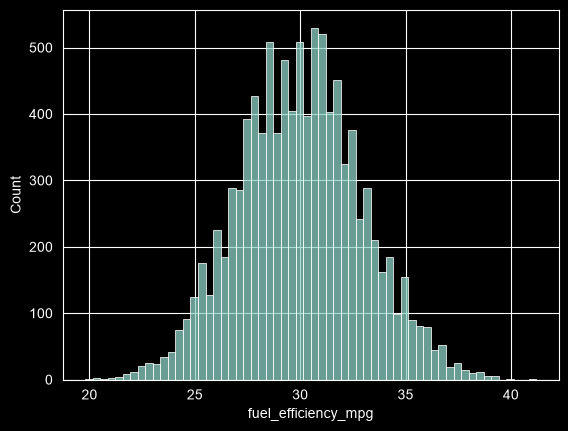

In [13]:
sns.histplot(df['fuel_efficiency_mpg'])

In [14]:
#Question 1

In [15]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [16]:
#Question 2

In [17]:
df.horsepower.median()

np.float64(254.0)

In [41]:
#Prepare dataset

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [42]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [90]:
def prepare_X(df, fillna_with):
    df = df.fillna(fillna_with)
    X = df.values
    return X

In [91]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [92]:
def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()

    return np.sqrt(mse)

In [93]:
X_train_zeroes = prepare_X(df_train, fillna_with=0)
X_train_mean = prepare_X(df_train, fillna_with=df.horsepower.mean())

In [94]:
w0_zero, w_zero = train_linear_regression(X_train_zeroes, y_train)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

In [95]:
X_val_zeroes = prepare_X(df_val, fillna_with=0)
X_val_mean = prepare_X(df_val, fillna_with=df.horsepower.mean())

In [96]:
y_val_pred_zero = w0_zero + X_val_zeroes.dot(w_zero)
y_val_pred_mean = w0_mean + X_val_mean.dot(w_mean)

In [97]:
round(rmse(y_val, y_val_pred_zero), 3), round(rmse(y_val, y_val_pred_mean), 3)

(np.float64(2.205), np.float64(2.202))

In [98]:
# Question 4

In [99]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [100]:
X_train_zeroes = prepare_X(df_train, fillna_with=0)
X_val_zeroes = prepare_X(df_val, fillna_with=df.horsepower.mean())

In [107]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train_zeroes, y_train, r=r)
    y_pred = w0 + X_val_zeroes.dot(w)

    print(f'{r}:', round(rmse(y_pred, y_val), 4))

0: 2.2053
0.01: 2.2052
0.1: 2.2219
1: 2.3564
5: 2.4226
10: 2.4338
100: 2.4445


In [108]:
# Question 5

In [124]:
#Prepare dataset

n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

rmse_results = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    df_train = df_train.reset_index(drop=True)
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train, fillna_with=0)
    X_val = prepare_X(df_val, fillna_with=0)

    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)

    rmse_results.append(round(rmse(y_pred, y_val), 4))


In [125]:
rmse_results

[np.float64(2.2392),
 np.float64(2.2021),
 np.float64(2.1634),
 np.float64(2.2044),
 np.float64(2.2019),
 np.float64(2.2458),
 np.float64(2.2697),
 np.float64(2.1908),
 np.float64(2.2166),
 np.float64(2.207)]

In [127]:
round(np.std(rmse_results), 3)

np.float64(0.029)

In [128]:
# Question 6

In [133]:
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [134]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

In [138]:
X_full_train = prepare_X(df_full_train, fillna_with=0)
X_full_train

array([[2320.,  246., 4100., 2014.],
       [2230.,  252., 4250., 1998.],
       [2700.,  276., 4490., 2008.],
       ...,
       [1800.,  225., 3980., 1994.],
       [1970.,  232., 3560., 2009.],
       [2180.,  254., 3970., 2018.]], shape=(8000, 4))

In [139]:
y_full_train = np.concat([y_train, y_val])
y_full_train

array([32.5, 33.2, 32.4, ..., 29.1, 32.2, 35.6], shape=(8000,))

In [140]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [141]:
X_test = prepare_X(df_test, fillna_with=0)

In [142]:
y_pred = w0 + X_test.dot(w)

In [143]:
round(rmse(y_pred, y_test), 3)

np.float64(2.236)